# GTSRB Traffic Sign Recognition with Data Augmentation

In [2]:
import torch
import torchvision
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import os

import sys
sys.path.insert(1, '../util')
import vcpi_util

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

BASE_PATH     = '..'                           
PATH_TRAIN    = f'{BASE_PATH}/images/train_images'
PATH_TEST     = f'{BASE_PATH}/images/test_images'
PATH_MODELS   = f'{BASE_PATH}/models'

BATCH_SIZE = 32
EPOCHS     = 50
RUNS       = 1   # professor disse mínimo 5 runs, fazer média
NUM_CLASSES = 43  # pastas 00000 a 00042

IMG_SIZE_CONV = 32  # GTSRB usa 32x32
IMG_SIZE_VGG = 64

cuda:0


## Auxiliar Functions

In [4]:
class EarlyStopping:
    def __init__(self, patience=9, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_val_loss = float('inf')

    def __call__(self, val_loss):
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True
        return False


def train(model, train_loader, val_loader, epochs, loss_fn, optimizer,
          scheduler, early_stopper, save_path):
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = np.inf

    for epoch in range(epochs):
        model.train()
        running_loss, correct = 0.0, 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            loss = loss_fn(outputs, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            correct += (predicted == targets).sum()

        model.eval()
        val_loss, v_correct = 0.0, 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                val_loss += loss_fn(outputs, targets).item() * targets.size(0)
                v_correct += (preds == targets).sum()

        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        if old_lr != new_lr:
            print(f'  LR: {old_lr} → {new_lr}')

        epoch_loss = running_loss / len(train_loader.dataset)
        acc        = 100 * correct / len(train_loader.dataset)
        v_acc      = 100 * v_correct / len(val_loader.dataset)
        val_loss  /= len(val_loader.dataset)

        history['loss'].append(epoch_loss)
        history['accuracy'].append(acc.cpu().numpy())
        history['val_loss'].append(val_loss)
        history['val_acc'].append(v_acc.cpu().numpy())

        print(f'Epoch {epoch:03d} | Loss: {epoch_loss:.4f} | Acc: {acc:.2f}% '
              f'| Val Loss: {val_loss:.4f} | Val Acc: {v_acc:.2f}%')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({'epoch': epoch, 'model': model.state_dict(),
                        'optimizer': optimizer.state_dict(),
                        'scheduler': scheduler.state_dict()}, save_path)

        if early_stopper(val_loss):
            print('Early stopping!')
            break

    print('Treino concluído.\n')
    return history


def evaluate(model, data_loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, targets in data_loader:
            outputs = model(images.to(device))
            _, preds = torch.max(outputs, 1)
            correct += (preds.cpu() == targets).sum()
    return (correct / len(data_loader.dataset)).item()


def run_experiment(name, transform_train, transform_test, model_name='conv_II', n_runs=RUNS):
    print(f'\n{"="*60}')
    print(f'EXPERIÊNCIA: {name}')
    print(f'{"="*60}')

    # Divisão treino/validação (80/20) a partir do train_images
    full_train = torchvision.datasets.ImageFolder(
        root=PATH_TRAIN, transform=transform_train)
    
    val_size   = int(0.2 * len(full_train))
    train_size = len(full_train) - val_size
    train_set, val_set = torch.utils.data.random_split(
        full_train, [train_size, val_size],
        generator=torch.Generator().manual_seed(42))

    val_set.dataset.transform = transform_base_vgg if model_name in ('vgg16','vgg16_tl') else transform_base

    test_set = torchvision.datasets.ImageFolder(
        root=PATH_TEST, transform=transform_test)

    train_loader = torch.utils.data.DataLoader(
        train_set, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = torch.utils.data.DataLoader(
        val_set,   batch_size=BATCH_SIZE)
    test_loader  = torch.utils.data.DataLoader(
        test_set,  batch_size=BATCH_SIZE)

    results = []
    for i in range(n_runs):
        print(f'\n--- Run {i+1}/{n_runs} ---')
        
        if model_name == 'conv_II':
            model = conv_II(NUM_CLASSES).to(device)
        elif model_name == 'vgg16':
            model = torchvision.models.vgg16()
            n_inputs = model.classifier[0].in_features
            model.classifier = torch.nn.Sequential(
                torch.nn.Linear(n_inputs, 256),
                torch.nn.ReLU(),
                torch.nn.Dropout(0.5),
                torch.nn.Linear(256, NUM_CLASSES)
            )
            model.to(device)
        elif model_name == 'vgg16_tl':
            model = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)
            for param in model.parameters():
                param.requires_grad = False
            n_inputs = model.classifier[0].in_features
            model.classifier = torch.nn.Sequential(
                torch.nn.Linear(n_inputs, 256),
                torch.nn.ReLU(),
                torch.nn.Dropout(0.5),
                torch.nn.Linear(256, NUM_CLASSES)
            )
            model.to(device)
        
        loss_fn    = torch.nn.CrossEntropyLoss()
        optimizer  = torch.optim.Adam(model.parameters())
        scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
                         optimizer, mode='min', factor=0.1, patience=3)
        early_stop = EarlyStopping(patience=9)
        save_path  = f'{PATH_MODELS}/{model_name}_{name}_run{i}.pt'

        history = train(model, train_loader, val_loader, EPOCHS,
                        loss_fn, optimizer, scheduler, early_stop, save_path)

        # Recarregar melhor checkpoint
        checkpoint = torch.load(save_path)
        model.load_state_dict(checkpoint['model'])
        acc = evaluate(model, test_loader)
        print(f'Test Accuracy (run {i}): {acc*100:.2f}%')
        results.append(acc)

    mean_acc = np.mean(results)
    std_acc  = np.std(results)
    print(f'\n→ {name}: média = {mean_acc*100:.2f}% | std = {std_acc*100:.2f}%')
    return results, mean_acc, std_acc


## Dataset Analysis

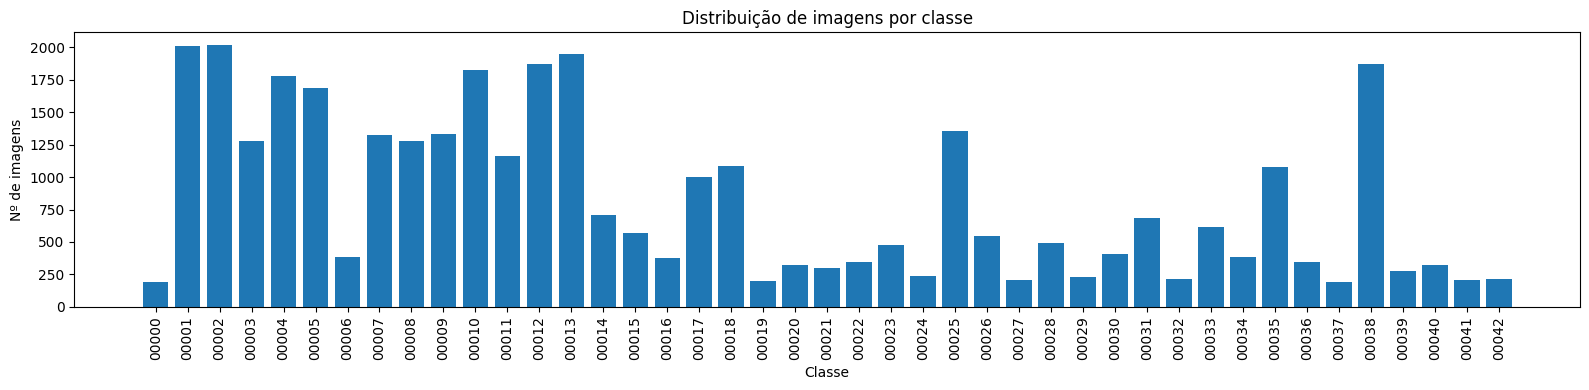

Classe com mais imagens:  00002 (2016 imgs)
Classe com menos imagens: 00000 (188 imgs)


In [4]:
from collections import Counter
import pathlib

class_counts = Counter()
for cls in sorted(os.listdir(PATH_TRAIN)):
    cls_path = os.path.join(PATH_TRAIN, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len(list(pathlib.Path(cls_path).glob('*.ppm')))

plt.figure(figsize=(16,4))
plt.bar(class_counts.keys(), class_counts.values())
plt.title('Distribuição de imagens por classe')
plt.xlabel('Classe')
plt.ylabel('Nº de imagens')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(f"Classe com mais imagens:  {max(class_counts, key=class_counts.get)} ({max(class_counts.values())} imgs)")
print(f"Classe com menos imagens: {min(class_counts, key=class_counts.get)} ({min(class_counts.values())} imgs)")

In [6]:
transform_base = v2.Compose([
    v2.Resize((IMG_SIZE_CONV, IMG_SIZE_CONV)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

transform_base_vgg = v2.Compose([
    v2.Resize((IMG_SIZE_VGG, IMG_SIZE_VGG)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

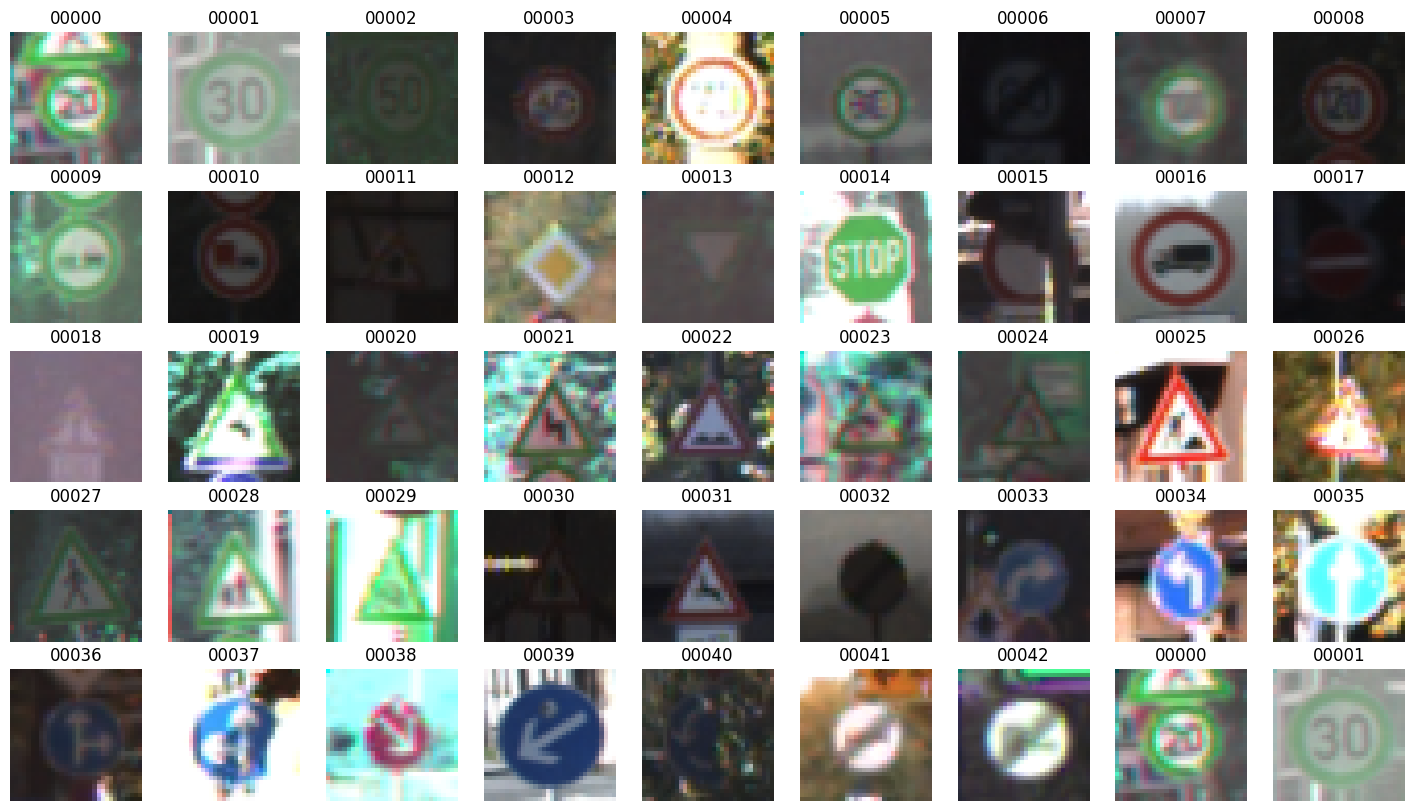

<Figure size 640x480 with 0 Axes>

In [6]:
train_set_visualization = torchvision.datasets.ImageFolder(
        root=PATH_TRAIN, transform=transform_base)

train_loader_visualization = torch.utils.data.DataLoader(
        train_set_visualization, batch_size=BATCH_SIZE, shuffle=True)

#images, targets = next(iter(train_loader_visualization))
#print("Batch shape: ", images.shape)

#print(targets)

class_to_idx = {}
for idx, (_, label) in enumerate(train_set_visualization.samples):
    if label not in class_to_idx:
        class_to_idx[label] = idx
    if len(class_to_idx) == NUM_CLASSES:
        break

indices = [class_to_idx[c] for c in sorted(class_to_idx)]
images  = torch.stack([train_set_visualization[i][0] for i in indices])
targets = torch.tensor(sorted(class_to_idx.keys()))
rows, cols = 5, 9
n = rows * cols

images_padded  = torch.cat([images,  images[:n - len(images)]])
targets_padded = torch.cat([targets, targets[:n - len(targets)]])

vcpi_util.show_images(rows, cols, images_padded, targets_padded,
                      train_set_visualization.classes)

## Model

In [7]:
class conv_II(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1   = torch.nn.Conv2d(3, 16, 3)
        self.bn1     = torch.nn.BatchNorm2d(16)
        self.relu1   = torch.nn.ReLU()
        self.conv2   = torch.nn.Conv2d(16, 32, 3)
        self.bn2     = torch.nn.BatchNorm2d(32)
        self.relu2   = torch.nn.ReLU()
        self.maxpool1 = torch.nn.MaxPool2d(2)
        self.conv3   = torch.nn.Conv2d(32, 48, 3)
        self.bn3     = torch.nn.BatchNorm2d(48)
        self.relu3   = torch.nn.ReLU()
        self.conv4   = torch.nn.Conv2d(48, 48, 3)
        self.bn4     = torch.nn.BatchNorm2d(48)
        self.relu4   = torch.nn.ReLU()
        self.maxpool2 = torch.nn.MaxPool2d(2)
        self.dropout = torch.nn.Dropout(p=0.5)
        self.fc1     = torch.nn.Linear(48, num_classes)

    def forward(self, x):
        x = self.relu1(self.bn1(self.conv1(x)))
        x = self.relu2(self.bn2(self.conv2(x)))
        x = self.maxpool1(x)
        x = self.relu3(self.bn3(self.conv3(x)))
        x = self.relu4(self.bn4(self.conv4(x)))
        x = self.maxpool2(x)
        x = torch.mean(x, dim=[2, 3])  
        x = self.dropout(x)
        x = self.fc1(x)
        return x

In [8]:
all_results = []

## Experience 0 - Baseline

In [14]:
for model_name in ['conv_II', 'vgg16', 'vgg16_tl']:
    t_base = transform_base_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_base
    _, mean, std = run_experiment(
        name='baseline',
        transform_train=t_base,
        transform_test=t_base,
        model_name=model_name
    )
    all_results.append({'Modelo': model_name, 'Experiência': 'Baseline', 'Média (%)': round(mean*100,2), 'Std (%)': round(std*100,3)})


EXPERIÊNCIA: baseline

--- Run 1/1 ---
Epoch 000 | Loss: 2.5587 | Acc: 28.36% | Val Loss: 1.7625 | Val Acc: 54.07%
Epoch 001 | Loss: 1.6008 | Acc: 52.04% | Val Loss: 0.9924 | Val Acc: 71.78%
Epoch 002 | Loss: 1.0558 | Acc: 68.37% | Val Loss: 0.6216 | Val Acc: 81.92%
Epoch 003 | Loss: 0.7274 | Acc: 78.58% | Val Loss: 0.3767 | Val Acc: 93.82%
Epoch 004 | Loss: 0.5225 | Acc: 85.11% | Val Loss: 0.1989 | Val Acc: 96.73%
Epoch 005 | Loss: 0.4048 | Acc: 88.65% | Val Loss: 0.1501 | Val Acc: 97.38%
Epoch 006 | Loss: 0.3290 | Acc: 90.61% | Val Loss: 0.1432 | Val Acc: 97.82%
Epoch 007 | Loss: 0.2701 | Acc: 92.36% | Val Loss: 0.0870 | Val Acc: 98.80%
Epoch 008 | Loss: 0.2443 | Acc: 93.12% | Val Loss: 0.0682 | Val Acc: 98.85%
Epoch 009 | Loss: 0.2072 | Acc: 94.12% | Val Loss: 0.0658 | Val Acc: 98.84%
Epoch 010 | Loss: 0.1882 | Acc: 94.64% | Val Loss: 0.0462 | Val Acc: 99.05%
Epoch 011 | Loss: 0.1665 | Acc: 95.32% | Val Loss: 0.0379 | Val Acc: 99.18%
Epoch 012 | Loss: 0.1526 | Acc: 95.64% | Val Los

## Experience 1 - Augmentation Geométrica

In [16]:
transform_geo = v2.Compose([
    v2.RandomRotation(15, interpolation=v2.InterpolationMode.BILINEAR),
    v2.Resize((IMG_SIZE_CONV, IMG_SIZE_CONV)),
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

transform_geo_vgg = v2.Compose([
    v2.RandomRotation(15, interpolation=v2.InterpolationMode.BILINEAR),
    v2.Resize((IMG_SIZE_VGG, IMG_SIZE_VGG)),
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

#results_geo, mean_geo, std_geo = run_experiment(
#    name='aug_geometrica',
#    transform_train=transform_geo,
#    transform_test=transform_base
#)

for model_name in ['conv_II', 'vgg16', 'vgg16_tl']:
    t_base = transform_base_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_base
    t_train = transform_geo_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_geo
    _, mean, std = run_experiment(
        name='geo',
        transform_train=t_train,
        transform_test=t_base,
        model_name=model_name
    )
    all_results.append({'Modelo': model_name, 'Experiência': 'Geométrica', 'Média (%)': round(mean*100,2), 'Std (%)': round(std*100,3)})


EXPERIÊNCIA: baseline

--- Run 1/1 ---
Epoch 000 | Loss: 2.5022 | Acc: 30.89% | Val Loss: 1.5705 | Val Acc: 56.77%
Epoch 001 | Loss: 1.4895 | Acc: 55.53% | Val Loss: 0.9181 | Val Acc: 76.14%
Epoch 002 | Loss: 0.9834 | Acc: 70.78% | Val Loss: 0.4782 | Val Acc: 90.06%
Epoch 003 | Loss: 0.6748 | Acc: 80.37% | Val Loss: 0.2819 | Val Acc: 95.90%
Epoch 004 | Loss: 0.4886 | Acc: 86.00% | Val Loss: 0.1955 | Val Acc: 96.66%
Epoch 005 | Loss: 0.3790 | Acc: 89.23% | Val Loss: 0.1379 | Val Acc: 98.47%
Epoch 006 | Loss: 0.3015 | Acc: 91.63% | Val Loss: 0.1079 | Val Acc: 97.54%
Epoch 007 | Loss: 0.2585 | Acc: 92.59% | Val Loss: 0.0675 | Val Acc: 99.05%
Epoch 008 | Loss: 0.2205 | Acc: 93.87% | Val Loss: 0.0526 | Val Acc: 99.24%
Epoch 009 | Loss: 0.1894 | Acc: 94.76% | Val Loss: 0.0422 | Val Acc: 99.14%
Epoch 010 | Loss: 0.1729 | Acc: 95.06% | Val Loss: 0.0422 | Val Acc: 99.11%
Epoch 011 | Loss: 0.1629 | Acc: 95.53% | Val Loss: 0.0457 | Val Acc: 99.07%
Epoch 012 | Loss: 0.1504 | Acc: 95.74% | Val Los

## Experience 2 - Augmentation Geométrica 2

In [17]:
transform_geo2 = v2.Compose([
    v2.RandomPerspective(distortion_scale=0.2, p=0.6),
    v2.Resize((IMG_SIZE_CONV +8, IMG_SIZE_CONV +8)),
    v2.RandomCrop((IMG_SIZE_CONV, IMG_SIZE_CONV)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

transform_geo2_vgg = v2.Compose([
    v2.RandomPerspective(distortion_scale=0.2, p=0.6),
    v2.Resize((IMG_SIZE_VGG +8, IMG_SIZE_VGG +8)),
    v2.RandomCrop((IMG_SIZE_VGG, IMG_SIZE_VGG)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

#results_geo2, mean_geo2, std_geo2 = run_experiment(
#    name='aug_geometrica2',
#    transform_train=transform_geo2,
#    transform_test=transform_base
#)

for model_name in ['conv_II', 'vgg16', 'vgg16_tl']:
    t_base = transform_base_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_base
    t_train = transform_geo2_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_geo2
    _, mean, std = run_experiment(
        name='geo2',
        transform_train=t_train,
        transform_test=t_base,
        model_name=model_name
    )
    all_results.append({'Modelo': model_name, 'Experiência': 'Geométrica 2', 'Média (%)': round(mean*100,2), 'Std (%)': round(std*100,3)})


EXPERIÊNCIA: baseline

--- Run 1/1 ---
Epoch 000 | Loss: 2.5767 | Acc: 27.93% | Val Loss: 1.8320 | Val Acc: 43.74%
Epoch 001 | Loss: 1.5895 | Acc: 51.95% | Val Loss: 1.0574 | Val Acc: 73.02%
Epoch 002 | Loss: 1.0415 | Acc: 69.03% | Val Loss: 0.5854 | Val Acc: 87.01%
Epoch 003 | Loss: 0.6986 | Acc: 79.27% | Val Loss: 0.3342 | Val Acc: 92.76%
Epoch 004 | Loss: 0.5036 | Acc: 85.55% | Val Loss: 0.2126 | Val Acc: 96.49%
Epoch 005 | Loss: 0.3900 | Acc: 88.94% | Val Loss: 0.1421 | Val Acc: 97.54%
Epoch 006 | Loss: 0.3110 | Acc: 91.21% | Val Loss: 0.1001 | Val Acc: 98.32%
Epoch 007 | Loss: 0.2642 | Acc: 92.53% | Val Loss: 0.0809 | Val Acc: 98.57%
Epoch 008 | Loss: 0.2230 | Acc: 93.84% | Val Loss: 0.0531 | Val Acc: 99.08%
Epoch 009 | Loss: 0.1993 | Acc: 94.43% | Val Loss: 0.0502 | Val Acc: 99.00%
Epoch 010 | Loss: 0.1851 | Acc: 94.74% | Val Loss: 0.0453 | Val Acc: 99.12%
Epoch 011 | Loss: 0.1595 | Acc: 95.45% | Val Loss: 0.0460 | Val Acc: 99.29%
Epoch 012 | Loss: 0.1516 | Acc: 95.74% | Val Los

## Experience 3 - Augmentation de Cor

In [18]:
transform_color = v2.Compose([
    v2.Resize((IMG_SIZE_CONV, IMG_SIZE_CONV)),
    v2.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.3, hue=0.05),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

transform_color_vgg = v2.Compose([
    v2.Resize((IMG_SIZE_VGG, IMG_SIZE_VGG)),
    v2.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.3, hue=0.05),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

#results_color, mean_color, std_color = run_experiment(
#    name='aug_cor',
#    transform_train=transform_color,
#    transform_test=transform_base
#)

for model_name in ['conv_II', 'vgg16', 'vgg16_tl']:
    t_base = transform_base_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_base
    t_train = transform_color_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_color
    _, mean, std = run_experiment(
        name='color',
        transform_train=t_train,
        transform_test=t_base,
        model_name=model_name
    )
    all_results.append({'Modelo': model_name, 'Experiência': 'Cor', 'Média (%)': round(mean*100,2), 'Std (%)': round(std*100,3)})


EXPERIÊNCIA: baseline

--- Run 1/1 ---
Epoch 000 | Loss: 2.5113 | Acc: 29.64% | Val Loss: 1.6797 | Val Acc: 53.49%
Epoch 001 | Loss: 1.5389 | Acc: 54.03% | Val Loss: 0.9969 | Val Acc: 76.69%
Epoch 002 | Loss: 1.0210 | Acc: 69.55% | Val Loss: 0.5292 | Val Acc: 86.72%
Epoch 003 | Loss: 0.7167 | Acc: 78.67% | Val Loss: 0.3910 | Val Acc: 92.73%
Epoch 004 | Loss: 0.5239 | Acc: 85.01% | Val Loss: 0.2196 | Val Acc: 95.23%
Epoch 005 | Loss: 0.4074 | Acc: 88.35% | Val Loss: 0.1359 | Val Acc: 97.76%
Epoch 006 | Loss: 0.3250 | Acc: 90.86% | Val Loss: 0.1355 | Val Acc: 97.58%
Epoch 007 | Loss: 0.2780 | Acc: 92.32% | Val Loss: 0.0930 | Val Acc: 98.60%
Epoch 008 | Loss: 0.2371 | Acc: 93.14% | Val Loss: 0.0692 | Val Acc: 98.83%
Epoch 009 | Loss: 0.2025 | Acc: 94.37% | Val Loss: 0.0674 | Val Acc: 98.59%
Epoch 010 | Loss: 0.1862 | Acc: 94.68% | Val Loss: 0.0503 | Val Acc: 99.12%
Epoch 011 | Loss: 0.1703 | Acc: 95.11% | Val Loss: 0.0547 | Val Acc: 98.87%
Epoch 012 | Loss: 0.1452 | Acc: 95.70% | Val Los

## Experience 4 - Augmentation Combinada (geo + cor + erasing)

In [19]:
transform_combined = v2.Compose([
    v2.RandomRotation(15, interpolation=v2.InterpolationMode.BILINEAR),
    v2.Resize((IMG_SIZE_CONV, IMG_SIZE_CONV)),
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    v2.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.3, hue=0.05),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.RandomErasing(p=0.3, scale=(0.02, 0.1), value='random')  # simula oclusão
])

transform_combined_vgg = v2.Compose([
    v2.RandomRotation(15, interpolation=v2.InterpolationMode.BILINEAR),
    v2.Resize((IMG_SIZE_VGG, IMG_SIZE_VGG)),
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    v2.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.3, hue=0.05),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.RandomErasing(p=0.3, scale=(0.02, 0.1), value='random'),  # simula oclusão
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

#results_comb, mean_comb, std_comb = run_experiment(
#    name='aug_combinada',
#    transform_train=transform_combined,
#    transform_test=transform_base
#)

for model_name in ['conv_II', 'vgg16', 'vgg16_tl']:
    t_base = transform_base_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_base
    t_train = transform_combined_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_combined
    _, mean, std = run_experiment(
        name='combined',
        transform_train=t_train,
        transform_test=t_base,
        model_name=model_name
    )
    all_results.append({'Modelo': model_name, 'Experiência': 'Combinada', 'Média (%)': round(mean*100,2), 'Std (%)': round(std*100,3)})


EXPERIÊNCIA: baseline

--- Run 1/1 ---
Epoch 000 | Loss: 2.5208 | Acc: 29.70% | Val Loss: 1.7739 | Val Acc: 50.09%
Epoch 001 | Loss: 1.5737 | Acc: 52.44% | Val Loss: 1.0424 | Val Acc: 73.43%
Epoch 002 | Loss: 1.0849 | Acc: 67.50% | Val Loss: 0.5899 | Val Acc: 84.54%
Epoch 003 | Loss: 0.7507 | Acc: 77.79% | Val Loss: 0.4106 | Val Acc: 91.40%
Epoch 004 | Loss: 0.5556 | Acc: 84.09% | Val Loss: 0.2041 | Val Acc: 96.69%
Epoch 005 | Loss: 0.4109 | Acc: 88.54% | Val Loss: 0.1355 | Val Acc: 98.15%
Epoch 006 | Loss: 0.3344 | Acc: 90.63% | Val Loss: 0.1099 | Val Acc: 98.19%
Epoch 007 | Loss: 0.2790 | Acc: 92.04% | Val Loss: 0.0899 | Val Acc: 98.80%
Epoch 008 | Loss: 0.2361 | Acc: 93.28% | Val Loss: 0.0679 | Val Acc: 99.07%
Epoch 009 | Loss: 0.2092 | Acc: 94.20% | Val Loss: 0.0610 | Val Acc: 99.02%
Epoch 010 | Loss: 0.1870 | Acc: 94.61% | Val Loss: 0.0482 | Val Acc: 99.25%
Epoch 011 | Loss: 0.1673 | Acc: 95.35% | Val Loss: 0.0535 | Val Acc: 99.17%
Epoch 012 | Loss: 0.1596 | Acc: 95.61% | Val Los

## Experience 5 - Expansão Massiva do Dataset

In [9]:
transform_strong = v2.Compose([
    v2.RandomRotation(20, interpolation=v2.InterpolationMode.BILINEAR),
    v2.Resize((IMG_SIZE_CONV, IMG_SIZE_CONV)),
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    v2.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.3, hue=0.05),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.RandomErasing(p=0.3, scale=(0.02, 0.1), value='random')
])

transform_strong_vgg = v2.Compose([
    v2.RandomRotation(20, interpolation=v2.InterpolationMode.BILINEAR),
    v2.Resize((IMG_SIZE_VGG, IMG_SIZE_VGG)),
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    v2.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.3, hue=0.05),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.RandomErasing(p=0.3, scale=(0.02, 0.1), value='random'),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Dataset expandido = original + versão augmentada
#full_original  = torchvision.datasets.ImageFolder(root=PATH_TRAIN, transform=transform_base)
#full_augmented = torchvision.datasets.ImageFolder(root=PATH_TRAIN, transform=transform_strong)
#expanded_dataset = torch.utils.data.ConcatDataset([full_original, full_augmented])

#train_size_exp = int(0.8 * len(expanded_dataset))
#val_size_exp   = len(expanded_dataset) - train_size_exp
#train_exp, val_exp = torch.utils.data.random_split(
#    expanded_dataset, [train_size_exp, val_size_exp],
#    generator=torch.Generator().manual_seed(42))

#test_set = torchvision.datasets.ImageFolder(root=PATH_TEST, transform=transform_base)

#train_loader_exp = torch.utils.data.DataLoader(train_exp, batch_size=BATCH_SIZE, shuffle=True)
#val_loader_exp   = torch.utils.data.DataLoader(val_exp,   batch_size=BATCH_SIZE)
#test_loader      = torch.utils.data.DataLoader(test_set,  batch_size=BATCH_SIZE)

#results_exp = []
#for i in range(RUNS):
#    print(f'\n--- Expansão Massiva Run {i+1}/{RUNS} ---')
#    model     = conv_II(NUM_CLASSES).to(device)
#    loss_fn   = torch.nn.CrossEntropyLoss()
#    optimizer = torch.optim.Adam(model.parameters())
#    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
#    early_stop = EarlyStopping(patience=9)
#    save_path  = f'{PATH_MODELS}/aug_expansao_run{i}.pt'
#    train(model, train_loader_exp, val_loader_exp, EPOCHS,
#          loss_fn, optimizer, scheduler, early_stop, save_path)
#    checkpoint = torch.load(save_path)
#    model.load_state_dict(checkpoint['model'])
#    acc = evaluate(model, test_loader)
#    print(f'Test Accuracy: {acc*100:.2f}%')
#    results_exp.append(acc)

#mean_exp = np.mean(results_exp)
#std_exp  = np.std(results_exp)
#print(f'\n→ Expansão Massiva: média = {mean_exp*100:.2f}% | std = {std_exp*100:.2f}%')



for model_name in ['conv_II', 'vgg16', 'vgg16_tl']:
    t_base   = transform_base_vgg  if model_name in ('vgg16', 'vgg16_tl') else transform_base
    t_strong = transform_strong_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_strong

    full_original  = torchvision.datasets.ImageFolder(root=PATH_TRAIN, transform=t_base)
    full_augmented = torchvision.datasets.ImageFolder(root=PATH_TRAIN, transform=t_strong)
    expanded_dataset = torch.utils.data.ConcatDataset([full_original, full_augmented])

    train_size_exp = int(0.8 * len(expanded_dataset))
    val_size_exp   = len(expanded_dataset) - train_size_exp
    train_exp, val_exp = torch.utils.data.random_split(
        expanded_dataset, [train_size_exp, val_size_exp],
        generator=torch.Generator().manual_seed(42))

    test_set = torchvision.datasets.ImageFolder(root=PATH_TEST, transform=t_base)

    train_loader_exp = torch.utils.data.DataLoader(train_exp, batch_size=BATCH_SIZE, shuffle=True)
    val_loader_exp   = torch.utils.data.DataLoader(val_exp,   batch_size=BATCH_SIZE)
    test_loader      = torch.utils.data.DataLoader(test_set,  batch_size=BATCH_SIZE)

    results_exp = []
    for i in range(RUNS):
        print(f'\n--- Expansão Massiva [{model_name}] Run {i+1}/{RUNS} ---')
        if model_name == 'conv_II':
            model = conv_II(NUM_CLASSES).to(device)
        elif model_name == 'vgg16':
            model = torchvision.models.vgg16()
            n_inputs = model.classifier[0].in_features
            model.classifier = torch.nn.Sequential(
                torch.nn.Linear(n_inputs, 256),
                torch.nn.ReLU(),
                torch.nn.Dropout(0.5),
                torch.nn.Linear(256, NUM_CLASSES)
            )
            model.to(device)
        elif model_name == 'vgg16_tl':
            model = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)
            for param in model.parameters():
                param.requires_grad = False
            n_inputs = model.classifier[0].in_features
            model.classifier = torch.nn.Sequential(
                torch.nn.Linear(n_inputs, 256),
                torch.nn.ReLU(),
                torch.nn.Dropout(0.5),
                torch.nn.Linear(256, NUM_CLASSES)
            )
            model.to(device)

        loss_fn    = torch.nn.CrossEntropyLoss()
        optimizer  = torch.optim.Adam(model.parameters())
        scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
        early_stop = EarlyStopping(patience=9)
        save_path  = f'{PATH_MODELS}/{model_name}_expansao_run{i}.pt'

        train(model, train_loader_exp, val_loader_exp, EPOCHS,
              loss_fn, optimizer, scheduler, early_stop, save_path)
        checkpoint = torch.load(save_path)
        model.load_state_dict(checkpoint['model'])
        acc = evaluate(model, test_loader)
        print(f'Test Accuracy: {acc*100:.2f}%')
        results_exp.append(acc)

    mean_exp = np.mean(results_exp)
    std_exp  = np.std(results_exp)
    print(f'\n→ Expansão Massiva [{model_name}]: média = {mean_exp*100:.2f}% | std = {std_exp*100:.2f}%')
    all_results.append({'Modelo': model_name, 'Experiência': 'Expansão Massiva', 'Média (%)': round(mean_exp*100,2), 'Std (%)': round(std_exp*100,3)})


--- Expansão Massiva [conv_II] Run 1/1 ---
Epoch 000 | Loss: 2.3913 | Acc: 31.79% | Val Loss: 1.3893 | Val Acc: 59.54%
Epoch 001 | Loss: 1.2521 | Acc: 62.46% | Val Loss: 0.7820 | Val Acc: 81.75%
Epoch 002 | Loss: 0.8072 | Acc: 76.48% | Val Loss: 0.5556 | Val Acc: 89.75%
Epoch 003 | Loss: 0.6108 | Acc: 82.27% | Val Loss: 0.3594 | Val Acc: 93.73%
Epoch 004 | Loss: 0.5121 | Acc: 85.36% | Val Loss: 0.2816 | Val Acc: 94.65%
Epoch 005 | Loss: 0.4369 | Acc: 87.36% | Val Loss: 0.2269 | Val Acc: 94.63%
Epoch 006 | Loss: 0.4007 | Acc: 88.33% | Val Loss: 0.2137 | Val Acc: 95.29%
Epoch 007 | Loss: 0.3616 | Acc: 89.43% | Val Loss: 0.1637 | Val Acc: 95.81%
Epoch 008 | Loss: 0.3325 | Acc: 90.27% | Val Loss: 0.1626 | Val Acc: 96.04%
Epoch 009 | Loss: 0.3193 | Acc: 90.63% | Val Loss: 0.1503 | Val Acc: 95.95%
Epoch 010 | Loss: 0.3085 | Acc: 91.05% | Val Loss: 0.1560 | Val Acc: 95.76%
Epoch 011 | Loss: 0.2771 | Acc: 91.97% | Val Loss: 0.1530 | Val Acc: 95.88%
Epoch 012 | Loss: 0.2663 | Acc: 92.13% | Val

## Experience 6 - Augmentation com MixUp e CutMix

In [10]:
def train_mixup(model, train_loader, val_loader, epochs, loss_fn, optimizer,
                scheduler, early_stopper, save_path):
    
    mixup = v2.MixUp(num_classes=NUM_CLASSES)
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = np.inf

    for epoch in range(epochs):
        model.train()
        running_loss, correct = 0.0, 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            # única diferença: aplica mixup ao batch antes do forward pass
            inputs, targets_mix = mixup(inputs, targets)
            
            outputs = model(inputs)
            loss = loss_fn(outputs, targets_mix)   # targets_mix são soft labels
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            # accuracy com labels originais (duras), não as soft
            _, predicted = torch.max(outputs, 1)
            hard = torch.argmax(targets_mix, dim=1)
            correct += (predicted == hard).sum()

        # validação igual ao train() original — sem mixup
        model.eval()
        val_loss, v_correct = 0.0, 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                val_loss += loss_fn(outputs,
                    torch.nn.functional.one_hot(targets, NUM_CLASSES).float()
                ).item() * targets.size(0)
                v_correct += (preds == targets).sum()

        # resto igual ao train() original
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        if old_lr != new_lr:
            print(f'  LR: {old_lr} → {new_lr}')

        epoch_loss = running_loss / len(train_loader.dataset)
        acc        = 100 * correct / len(train_loader.dataset)
        v_acc      = 100 * v_correct / len(val_loader.dataset)
        val_loss  /= len(val_loader.dataset)

        history['loss'].append(epoch_loss)
        history['accuracy'].append(acc.cpu().numpy())
        history['val_loss'].append(val_loss)
        history['val_acc'].append(v_acc.cpu().numpy())

        print(f'Epoch {epoch:03d} | Loss: {epoch_loss:.4f} | Acc: {acc:.2f}% '
              f'| Val Loss: {val_loss:.4f} | Val Acc: {v_acc:.2f}%')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({'epoch': epoch, 'model': model.state_dict(),
                        'optimizer': optimizer.state_dict(),
                        'scheduler': scheduler.state_dict()}, save_path)

        if early_stopper(val_loss):
            print('Early stopping!')
            break

    print('Treino concluído.\n')
    return history

In [11]:
def run_experiment_mix(name, transform_train, transform_test, model_name='conv_II', n_runs=RUNS):
    print(f'\n{"="*60}')
    print(f'EXPERIÊNCIA: {name}')
    print(f'{"="*60}')

    # Divisão treino/validação (80/20) a partir do train_images
    full_train = torchvision.datasets.ImageFolder(
        root=PATH_TRAIN, transform=transform_train)
    
    val_size   = int(0.2 * len(full_train))
    train_size = len(full_train) - val_size
    train_set, val_set = torch.utils.data.random_split(
        full_train, [train_size, val_size],
        generator=torch.Generator().manual_seed(42))

    val_set.dataset.transform = transform_base_vgg if model_name in ('vgg16','vgg16_tl') else transform_base

    test_set = torchvision.datasets.ImageFolder(
        root=PATH_TEST, transform=transform_test)

    train_loader = torch.utils.data.DataLoader(
        train_set, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = torch.utils.data.DataLoader(
        val_set,   batch_size=BATCH_SIZE)
    test_loader  = torch.utils.data.DataLoader(
        test_set,  batch_size=BATCH_SIZE)

    results = []
    for i in range(n_runs):
        print(f'\n--- Run {i+1}/{n_runs} ---')

        if model_name == 'conv_II':
            model = conv_II(NUM_CLASSES).to(device)
        elif model_name == 'vgg16':
            model = torchvision.models.vgg16()
            n_inputs = model.classifier[0].in_features
            model.classifier = torch.nn.Sequential(
                torch.nn.Linear(n_inputs, 256),
                torch.nn.ReLU(),
                torch.nn.Dropout(0.5),
                torch.nn.Linear(256, NUM_CLASSES)
            )
            model.to(device)
        elif model_name == 'vgg16_tl':
            model = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)
            for param in model.parameters():
                param.requires_grad = False
            n_inputs = model.classifier[0].in_features
            model.classifier = torch.nn.Sequential(
                torch.nn.Linear(n_inputs, 256),
                torch.nn.ReLU(),
                torch.nn.Dropout(0.5),
                torch.nn.Linear(256, NUM_CLASSES)
            )
            model.to(device)
        
        loss_fn    = torch.nn.CrossEntropyLoss()
        optimizer  = torch.optim.Adam(model.parameters())
        scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
                         optimizer, mode='min', factor=0.1, patience=3)
        early_stop = EarlyStopping(patience=9)
        save_path  = f'{PATH_MODELS}/{name}_run{i}.pt'

        history = train_mixup(model, train_loader, val_loader, EPOCHS,
                        loss_fn, optimizer, scheduler, early_stop, save_path)

        # Recarregar melhor checkpoint
        checkpoint = torch.load(save_path)
        model.load_state_dict(checkpoint['model'])
        acc = evaluate(model, test_loader)
        print(f'Test Accuracy (run {i}): {acc*100:.2f}%')
        results.append(acc)

    mean_acc = np.mean(results)
    std_acc  = np.std(results)
    print(f'\n→ {name}: média = {mean_acc*100:.2f}% | std = {std_acc*100:.2f}%')
    return results, mean_acc, std_acc


In [12]:
transform_mix = v2.Compose([
    v2.Resize((IMG_SIZE_CONV, IMG_SIZE_CONV)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

transform_mix_vgg = v2.Compose([
    v2.Resize((IMG_SIZE_VGG, IMG_SIZE_VGG)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

#results_mix, mean_mix, std_mix = run_experiment_mix(
#    name='aug_mix',
#    transform_train=transform_mix,
#    transform_test=transform_base
#)

for model_name in ['conv_II', 'vgg16', 'vgg16_tl']:
    t_base = transform_base_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_base
    t_train = transform_mix_vgg if model_name in ('vgg16', 'vgg16_tl') else transform_mix
    _, mean, std = run_experiment(
        name='mix',
        transform_train=t_train,
        transform_test=t_base,
        model_name=model_name
    )
    all_results.append({'Modelo': model_name, 'Experiência': 'CutMix e MixUp', 'Média (%)': round(mean*100,2), 'Std (%)': round(std*100,3)})


EXPERIÊNCIA: baseline

--- Run 1/1 ---
Epoch 000 | Loss: 2.4938 | Acc: 29.79% | Val Loss: 1.8300 | Val Acc: 44.01%
Epoch 001 | Loss: 1.5385 | Acc: 53.76% | Val Loss: 1.1395 | Val Acc: 66.81%
Epoch 002 | Loss: 1.0511 | Acc: 68.12% | Val Loss: 0.6045 | Val Acc: 82.83%
Epoch 003 | Loss: 0.7262 | Acc: 78.34% | Val Loss: 0.3797 | Val Acc: 90.65%
Epoch 004 | Loss: 0.5394 | Acc: 84.32% | Val Loss: 0.2492 | Val Acc: 96.62%
Epoch 005 | Loss: 0.4150 | Acc: 88.04% | Val Loss: 0.1564 | Val Acc: 97.38%
Epoch 006 | Loss: 0.3314 | Acc: 90.66% | Val Loss: 0.1056 | Val Acc: 98.06%
Epoch 007 | Loss: 0.2774 | Acc: 92.21% | Val Loss: 0.1061 | Val Acc: 98.12%
Epoch 008 | Loss: 0.2481 | Acc: 92.77% | Val Loss: 0.0740 | Val Acc: 98.98%
Epoch 009 | Loss: 0.2053 | Acc: 94.14% | Val Loss: 0.0699 | Val Acc: 98.68%
Epoch 010 | Loss: 0.1927 | Acc: 94.53% | Val Loss: 0.0611 | Val Acc: 99.05%
Epoch 011 | Loss: 0.1709 | Acc: 95.17% | Val Loss: 0.0579 | Val Acc: 98.56%
Epoch 012 | Loss: 0.1580 | Acc: 95.40% | Val Los

## Tabela Comparativa de Resultados

In [22]:
print(pd.DataFrame(all_results))

      Modelo       Experiência  Média (%)  Std (%)
0    conv_II  Expansão Massiva      98.31      0.0
1      vgg16  Expansão Massiva       5.70      0.0
2   vgg16_tl  Expansão Massiva      63.51      0.0
3    conv_II          Baseline      97.19      0.0
4      vgg16          Baseline       5.70      0.0
5   vgg16_tl          Baseline      64.13      0.0
6    conv_II          Baseline      97.70      0.0
7      vgg16          Baseline       5.70      0.0
8   vgg16_tl          Baseline      63.85      0.0
9    conv_II          Baseline      97.46      0.0
10     vgg16          Baseline       5.70      0.0
11  vgg16_tl          Baseline      64.59      0.0
12   conv_II          Baseline      98.04      0.0
13     vgg16          Baseline       5.70      0.0
14  vgg16_tl          Baseline      63.12      0.0
15   conv_II          Baseline      97.62      0.0
16     vgg16          Baseline       5.70      0.0
17  vgg16_tl          Baseline      63.94      0.0
18   conv_II          Baseline 

In [21]:
#summary = pd.DataFrame({
#    'Experiência':    ['Baseline', 'Geométrica', 'Geométrica2', 'Cor', 'Combinada', 'Expansão Massiva', 'CutMix e MixUp'],
#    'Média Accuracy': [mean_base,  mean_geo, mean_geo2,     mean_color, mean_comb, mean_exp, mean_mix],
#    'Std':            [std_base,   std_geo, std_geo2,        std_color,  std_comb,  std_exp, std_mix]
#})
#summary['Média Accuracy (%)'] = (summary['Média Accuracy'] * 100).round(2)
#summary['Std (%)']            = (summary['Std'] * 100).round(3)
#print(summary[['Experiência', 'Média Accuracy (%)', 'Std (%)']])

# Gráfico de barras comparativo
#plt.figure(figsize=(10, 5))
#plt.bar(summary['Experiência'], summary['Média Accuracy (%)'],
#        yerr=summary['Std (%)'], capsize=5)
#plt.ylabel('Accuracy no teste (%)')
#plt.title('Comparação de estratégias de Data Augmentation — GTSRB')
#plt.xticks(rotation=15)
#plt.tight_layout()
#plt.show()


summary = pd.DataFrame(all_results)
print(summary.pivot(index='Experiência', columns='Modelo', values='Média (%)').to_string())

pivot = summary.pivot(index='Experiência', columns='Modelo', values='Média (%)')
pivot.plot(kind='bar', figsize=(12, 5), capsize=4)
plt.ylabel('Accuracy no teste (%)')
plt.title('Comparação de modelos × augmentação — GTSRB')
plt.xticks(rotation=15)
plt.legend(title='Modelo')
plt.tight_layout()
plt.show()

ValueError: Index contains duplicate entries, cannot reshape